# CyberGuard-AI: Enterprise Remediation 0-1 Knapsack Optimizer
### Business-Aware Vulnerability Remediation under Finite Sprint Budgets

This notebook runs the exact 0-1 knapsack remediation optimizer against the enterprise dataset and
displays results **derived directly from the solver at execution time** -- nothing in this notebook is
hand-typed or hardcoded.

**Optimization item**: each row of the dataset is one **asset-CVE remediation action** (an asset paired
with a specific CVE affecting it), not simply "a CVE" -- the same CVE can generate multiple independent
remediation actions if it affects multiple assets.

**Composite risk formulation** (unchanged from the original implementation):

$$\text{risk\_score}_i = \text{exploit\_prob}_i \times \text{business\_impact\_score}_i \times \text{exposure\_mult}_i \times \frac{\text{cvss\_score}_i}{10}$$

where

$$\text{exploit\_prob}_i = \text{clip}(\text{epss\_score}_i + (0.40 \text{ if } \text{kev}_i=1 \text{ else } 0),\ 0.001,\ 1.0)$$
$$\text{exposure\_mult}_i = 1.5 \text{ if internet-facing else } 1.0$$

> **Modeling assumptions, not empirical constants.** The `+0.40` KEV bump and the `1.5x` internet-exposure
> multiplier are documented modeling choices carried over unchanged from the original implementation.
> They are **not** fit to observed exploitation data, and nothing in this notebook claims otherwise.
> All "risk" figures below mean **modeled risk exposure addressed under this specific formula**,
> not a measured or predicted real-world reduction in breach probability or loss.

**0-1 Knapsack formulation** (exact, not heuristic):

$$\max \sum_i \text{risk\_score}_i \cdot x_i \quad \text{s.t.} \quad \sum_i \text{remediation\_hours}_i \cdot x_i \le B, \quad x_i \in \{0,1\}$$

Solved to **provable global optimality** with two independent exact solvers (Google OR-Tools and SciPy
HiGHS MILP branch-and-cut), cross-checked against each other at every budget.

**Comparison methods**:
1. **Exact 0-1 Knapsack** -- the optimizer above.
2. **Risk-per-hour greedy baseline** -- same composite `risk_score` objective as the exact optimizer,
   filled greedily by `risk_score / remediation_hours` instead of solved optimally. This is the fair
   greedy comparison point for the exact solver, since it shares the same objective.
3. **Naive CVSS-only greedy baseline** -- sorts by raw `cvss_score` alone, ignoring exploit probability,
   business impact, and exposure. This optimizes a **different** objective than the exact solver, and is
   included only as an "industry status quo" reference point -- not an apples-to-apples comparison.

In [1]:
import sys
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_project_root(marker="src/optimization/knapsack_solver.py"):
    # Walks upward from the notebook's working directory looking for the
    # src/optimization/knapsack_solver.py marker file, so this works
    # regardless of what the repo's top-level folder happens to be named.
    for candidate in [Path(".").resolve(), *Path(".").resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    # Fall back to the original convention-based guess.
    return Path("..").resolve() if Path("..").resolve().name == "CyberGuard-Ai" else Path(".").resolve()

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"Project root: {PROJECT_ROOT}")

from optimization.knapsack_solver import (
    compute_risk_scores,
    get_actionable_dataframe,
    KnapsackInputError,
    solve_knapsack,
    solve_knapsack_milp,
    solve_knapsack_ortools,
    solve_greedy_cvss,
    solve_greedy_risk_per_hour,
    compare_solvers,
    check_monotonicity,
    KEV_BONUS,
    INTERNET_EXPOSURE_MULTIPLIER,
    INTERNAL_EXPOSURE_MULTIPLIER,
)

print(f"Modeling assumptions in effect -- KEV_BONUS={KEV_BONUS}, "
      f"INTERNET_EXPOSURE_MULTIPLIER={INTERNET_EXPOSURE_MULTIPLIER}, "
      f"INTERNAL_EXPOSURE_MULTIPLIER={INTERNAL_EXPOSURE_MULTIPLIER}")

Project root: /home/claude/project


Modeling assumptions in effect -- KEV_BONUS=0.4, INTERNET_EXPOSURE_MULTIPLIER=1.5, INTERNAL_EXPOSURE_MULTIPLIER=1.0


## Step 1: Loading Enterprise Assets & Vulnerability Exposure Dataset

Loads `data/processed/cyberguard_master_enterprise_dataset.csv`. Each row is an asset-CVE remediation
action instance.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cyberguard_master_enterprise_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(raw_df):,d} asset-CVE remediation action rows across {raw_df['asset_id'].nunique()} assets.")

assets_summary = (
    raw_df.groupby(["asset_name", "criticality", "internet_exposure", "asset_type"])
    .size()
    .reset_index(name="remediation_action_count")
)
print("\nSample Enterprise Assets:")
print(assets_summary.head(10).to_string(index=False))

Loaded 2,000 asset-CVE remediation action rows across 30 assets.

Sample Enterprise Assets:
asset_name criticality  internet_exposure asset_type  remediation_action_count
   Asset 0         LOW                  0   Database                        64
   Asset 1    CRITICAL                  0      Cloud                        61
  Asset 10        HIGH                  0      Cloud                        64
  Asset 11   VERY_HIGH                  0     Server                        64
  Asset 12    CRITICAL                  0      Cloud                        67
  Asset 13    CRITICAL                  0     Server                        67
  Asset 14    CRITICAL                  1      Cloud                        72
  Asset 15    CRITICAL                  1      Cloud                        73
  Asset 16        HIGH                  1      Cloud                        68
  Asset 17         LOW                  0    Network                        70


## Step 2: Composite Risk Score + Input Validation

`compute_risk_scores` computes the (unchanged) composite risk formula and validates `kev` is a clean
binary indicator, imputes missing `cvss_score`/`epss_score` with the column median (raising if a column
is entirely missing), and raises `KnapsackInputError` rather than silently producing bad numbers.

`get_actionable_dataframe` filters to `open`/`in_progress` rows and validates:
- no missing/NaN/infinite `risk_score` or `remediation_hours`
- no negative `risk_score`
- no non-positive `remediation_hours`
- no duplicate actionable `asset_id` + `cve_id` remediation actions (each row must be one independent
  action; duplicates would silently double-count the same action in the optimizer)

In [3]:
try:
    scored_df = compute_risk_scores(raw_df)
    actionable_df = get_actionable_dataframe(scored_df)
except KnapsackInputError as e:
    raise SystemExit(f"Input validation failed -- fix the dataset before optimizing: {e}")

total_enterprise_risk = float(scored_df["risk_score"].sum())
total_actionable_risk = float(actionable_df["risk_score"].sum())

print(f"Total enterprise MODELED risk surface (all rows):        {total_enterprise_risk:,.2f}")
print(f"Actionable (open/in_progress) remediation actions:       {len(actionable_df):,d}")
print(f"Actionable MODELED risk surface:                         {total_actionable_risk:,.2f}")

Total enterprise MODELED risk surface (all rows):        930.14
Actionable (open/in_progress) remediation actions:       1,380
Actionable MODELED risk surface:                         635.44


## Step 3: Exact 0-1 Knapsack Optimization vs Two Greedy Baselines

For each sprint budget (5h, 10h, 20h, 40h) we run all three methods on the SAME actionable dataset and
also cross-check the two exact solvers (OR-Tools vs SciPy HiGHS MILP) against each other.

In [4]:
values = actionable_df["risk_score"].to_numpy()
weights = actionable_df["remediation_hours"].to_numpy()
budgets = [5.0, 10.0, 20.0, 40.0]

long_rows = []
allocations_by_budget = {}
exact_objectives = []
agreement_checks = []

for b in budgets:
    # --- exact optimizer (primary result) ---
    exact_idx, exact_val, exact_hrs, solver_used = solve_knapsack(values, weights, b)
    exact_objectives.append(exact_val)
    allocations_by_budget[b] = exact_idx

    # --- explicit cross-check between the two exact solvers ---
    agreement = compare_solvers(values, weights, b)
    agreement["solver_used_for_primary_result"] = solver_used
    agreement_checks.append(agreement)

    # --- baselines ---
    rph_idx, rph_val, rph_hrs = solve_greedy_risk_per_hour(actionable_df, b)
    cvss_idx, cvss_val, cvss_hrs = solve_greedy_cvss(actionable_df, b)

    for method, idx, val, hrs in [
        ("Exact 0-1 Knapsack", exact_idx, exact_val, exact_hrs),
        ("Risk-per-hour greedy baseline", rph_idx, rph_val, rph_hrs),
        ("Naive CVSS-only greedy baseline", cvss_idx, cvss_val, cvss_hrs),
    ]:
        pct = (val / total_actionable_risk * 100) if total_actionable_risk > 0 else 0.0
        long_rows.append({
            "method": method,
            "budget_hours": b,
            "hours_used": round(hrs, 2),
            "remediation_actions": int(len(idx)),
            "modeled_risk_score_addressed": round(val, 4),
            "pct_of_actionable_modeled_risk_addressed": round(pct, 4),
        })

results_df = pd.DataFrame(long_rows)
print("=" * 100)
print("  REMEDIATION OPTIMIZATION BENCHMARK ACROSS SPRINT BUDGETS (derived live from the solver)")
print("=" * 100)
print(results_df.to_string(index=False))

  REMEDIATION OPTIMIZATION BENCHMARK ACROSS SPRINT BUDGETS (derived live from the solver)
                         method  budget_hours  hours_used  remediation_actions  modeled_risk_score_addressed  pct_of_actionable_modeled_risk_addressed
             Exact 0-1 Knapsack           5.0        4.96                   14                       25.3893                                    3.9956
  Risk-per-hour greedy baseline           5.0        4.96                   14                       25.3893                                    3.9956
Naive CVSS-only greedy baseline           5.0        4.96                    3                        0.9347                                    0.1471
             Exact 0-1 Knapsack          10.0       10.00                   27                       39.4906                                    6.2147
  Risk-per-hour greedy baseline          10.0       10.00                   27                       39.4906                                    6.2147
Naiv

## Step 4: Validation Checks

These checks are asserted programmatically -- if any of them fail, the cell below raises instead of
silently reporting results anyway.

In [5]:
# --- 1. Budget respected + binary selection, for every budget/method combo ---
for b in budgets:
    idx = allocations_by_budget[b]
    hrs_used = float(weights[idx].sum()) if len(idx) else 0.0
    assert hrs_used <= b + 1e-6, f"Budget violated at {b}h: used {hrs_used}h"
    assert len(idx) == len(set(idx.tolist())), f"Duplicate remediation action selected at {b}h"
print("[Check] Every exact solution respects its budget and selects each action at most once: PASSED")

# --- 2. Objective equals sum of selected risk scores ---
for b in budgets:
    idx = allocations_by_budget[b]
    recomputed = float(values[idx].sum()) if len(idx) else 0.0
    row = results_df[(results_df.budget_hours == b) & (results_df.method == "Exact 0-1 Knapsack")].iloc[0]
    assert abs(recomputed - row["modeled_risk_score_addressed"]) < 1e-3, f"Objective mismatch at {b}h"
print("[Check] Exact objective equals the sum of selected risk_score values: PASSED")

# --- 3. Monotonicity of the EXACT objective across budgets (NOT applied to greedy baselines) ---
check_monotonicity(budgets, exact_objectives)
print("[Check] Exact objective is non-decreasing as budget increases (5h -> 10h -> 20h -> 40h): PASSED")

# --- 4. OR-Tools vs SciPy HiGHS MILP agreement ---
agreement_df = pd.DataFrame([
    {
        "budget_hours": c["capacity"],
        "scipy_milp_objective": c["scipy_milp"]["objective"],
        "ortools_objective": c["ortools"]["objective"] if c["ortools"] else None,
        "value_diff": c.get("value_diff"),
        "agree": c["agree"],
    }
    for c in agreement_checks
])
print("\nSolver agreement (OR-Tools vs SciPy HiGHS MILP):")
print(agreement_df.to_string(index=False))

disagreements = [c for c in agreement_checks if c["agree"] is False]
assert not disagreements, f"OR-Tools and SciPy MILP disagreed: {disagreements}"
print("\n[Check] OR-Tools and SciPy HiGHS MILP agree on the optimal objective at every budget: PASSED")

[Check] Every exact solution respects its budget and selects each action at most once: PASSED
[Check] Exact objective equals the sum of selected risk_score values: PASSED
[Check] Exact objective is non-decreasing as budget increases (5h -> 10h -> 20h -> 40h): PASSED

Solver agreement (OR-Tools vs SciPy HiGHS MILP):
 budget_hours  scipy_milp_objective  ortools_objective  value_diff  agree
          5.0             25.389306          25.389306         0.0   True
         10.0             39.490634          39.490634         0.0   True
         20.0             61.318046          61.318046         0.0   True
         40.0             94.644645          94.644645         0.0   True

[Check] OR-Tools and SciPy HiGHS MILP agree on the optimal objective at every budget: PASSED


## Step 5: Visualizing Modeled Risk Addressed by Method

All bar heights come directly from `results_df`, computed above -- nothing is annotated by hand.

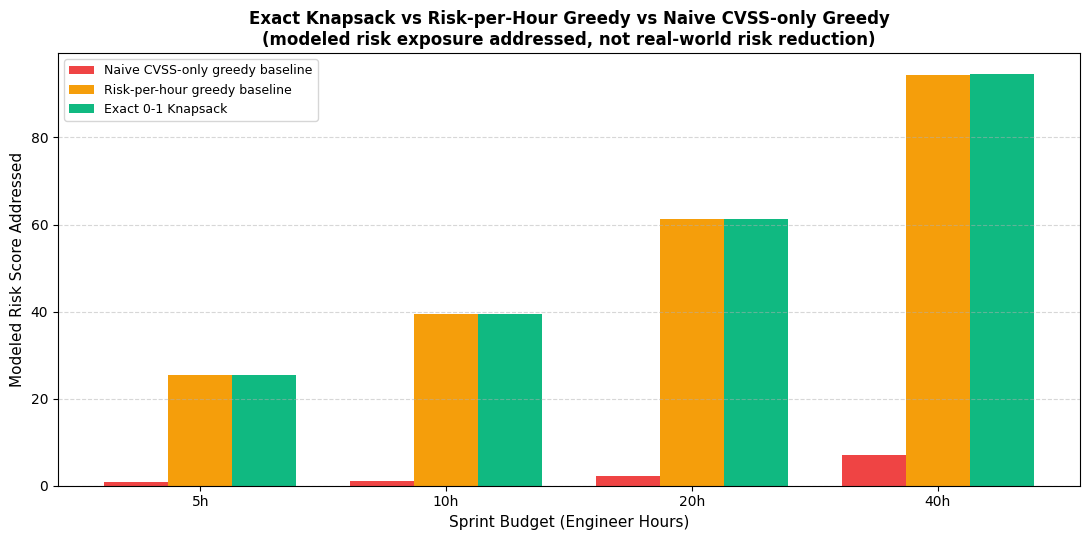

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
methods = ["Naive CVSS-only greedy baseline", "Risk-per-hour greedy baseline", "Exact 0-1 Knapsack"]
colors = {"Naive CVSS-only greedy baseline": "#EF4444",
          "Risk-per-hour greedy baseline": "#F59E0B",
          "Exact 0-1 Knapsack": "#10B981"}

x = np.arange(len(budgets))
w = 0.26
for i, method in enumerate(methods):
    sub = results_df[results_df.method == method].set_index("budget_hours").loc[budgets]
    ax.bar(x + (i - 1) * w, sub["modeled_risk_score_addressed"], w, label=method, color=colors[method])

ax.set_xlabel("Sprint Budget (Engineer Hours)", fontsize=11)
ax.set_ylabel("Modeled Risk Score Addressed", fontsize=11)
ax.set_title("Exact Knapsack vs Risk-per-Hour Greedy vs Naive CVSS-only Greedy\n(modeled risk exposure addressed, not real-world risk reduction)",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{b:g}h" for b in budgets])
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Step 6: Exact-Optimizer Gain Over Each Baseline

Computed live from `results_df` -- these are NOT hardcoded percentages.

In [7]:
pivot = results_df.pivot(index="budget_hours", columns="method", values="modeled_risk_score_addressed")
gain_vs_rph = (pivot["Exact 0-1 Knapsack"] - pivot["Risk-per-hour greedy baseline"]) / pivot["Risk-per-hour greedy baseline"] * 100
gain_vs_cvss = (pivot["Exact 0-1 Knapsack"] - pivot["Naive CVSS-only greedy baseline"]) / pivot["Naive CVSS-only greedy baseline"] * 100

gain_df = pd.DataFrame({
    "Exact 0-1 Knapsack": pivot["Exact 0-1 Knapsack"].round(3),
    "Risk-per-hour greedy": pivot["Risk-per-hour greedy baseline"].round(3),
    "Naive CVSS-only greedy": pivot["Naive CVSS-only greedy baseline"].round(3),
    "Gain vs risk-per-hour greedy (%)": gain_vs_rph.round(2),
    "Gain vs naive CVSS-only greedy (%)": gain_vs_cvss.round(2),
})
print(gain_df.to_string())

              Exact 0-1 Knapsack  Risk-per-hour greedy  Naive CVSS-only greedy  Gain vs risk-per-hour greedy (%)  Gain vs naive CVSS-only greedy (%)
budget_hours                                                                                                                                        
5.0                       25.389                25.389                   0.935                              0.00                             2616.30
10.0                      39.491                39.491                   1.187                              0.00                             3226.64
20.0                      61.318                61.318                   2.228                              0.00                             2652.53
40.0                      94.645                94.435                   7.090                              0.22                             1234.88


## Step 7: Actionable Sprint Patching Plan (10-Hour Sprint Example)

The concrete list of asset-CVE remediation actions selected by the **exact** optimizer for a 10-hour
sprint, pulled directly from the solved allocation -- not retyped.

In [8]:
example_budget = 10.0
idx_10h = allocations_by_budget[example_budget]
cols = ["cve_id", "asset_name", "criticality", "internet_exposure", "remediation_hours", "cvss_score", "risk_score"]
patch_plan_10h = (
    actionable_df.loc[idx_10h, cols]
    .rename(columns={"risk_score": "modeled_risk_score"})
    .sort_values(by="modeled_risk_score", ascending=False)
)

print("=" * 95)
print(f"  CYBERGUARD SPRINT PATCHING SCHEDULE: {example_budget:g}-HOUR ALLOCATION (exact optimizer)")
print("=" * 95)
print(patch_plan_10h.to_string(index=False))
print(f"\nTotal hours used: {weights[idx_10h].sum():.2f}h / {example_budget:g}h budget")
print(f"Total modeled risk score addressed: {values[idx_10h].sum():.4f}")

  CYBERGUARD SPRINT PATCHING SCHEDULE: 10-HOUR ALLOCATION (exact optimizer)
        cve_id asset_name criticality  internet_exposure  remediation_hours  cvss_score  modeled_risk_score
CVE-2023-67851    Asset 3        HIGH                  1               0.68         5.3            3.066961
CVE-2023-84960    Asset 3        HIGH                  1               0.48         4.8            2.910338
CVE-2023-34362   Asset 22         LOW                  0               0.54         7.3            2.661349
CVE-2023-52119    Asset 7    CRITICAL                  1               0.96         7.0            2.530416
CVE-2023-59469   Asset 15    CRITICAL                  1               0.25         7.1            2.425165
CVE-2023-16465    Asset 6         LOW                  0               0.39         7.6            2.385334
CVE-2023-72972    Asset 4        HIGH                  1               0.29         4.8            2.270471
CVE-2023-55269   Asset 20        HIGH                  0    

## Limitations

- `KEV_BONUS` (+0.40) and `INTERNET_EXPOSURE_MULTIPLIER` (1.5x) are modeling assumptions carried over
  unchanged from the original formula -- not empirically fit constants.
- "Modeled risk score addressed" assumes remediating an action fully eliminates its modeled risk
  contribution; it does not model partial mitigation, residual risk, or dependencies between actions.
- ML-predicted exploit probabilities are **not** wired into this optimizer in this notebook; `epss_score`
  and `kev` are used directly from the dataset as provided.
- All results in this notebook are **modeled risk exposure addressed**, not a measured or predicted
  real-world reduction in breach probability or financial loss.